# Bitcoin Market Sentiment Analysis

## Objective

To analyzes the relationship between Bitcoin market sentiment and trader performance using historical trading data and Fear & Greed Index.

In [2]:
#Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot') #using for better plots

pd.set_option('display.max_columns', None) #To show all the columns

## Part-A: Data preparation


In [3]:
#Loading datasets

trades = pd.read_csv('historical_data.csv')

sentiment = pd.read_csv('fear_greed_index.csv')

In [4]:
print("TRADES DATASET")
display(trades.head())

print("\nSENTIMENT DATASET")
display(sentiment.head())

TRADES DATASET


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



SENTIMENT DATASET


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:

print("Trades dataset shape:", trades.shape)
print("Sentiment dataset shape:", sentiment.shape)

Trades dataset shape: (211224, 16)
Sentiment dataset shape: (2644, 4)


In [6]:
#bringing in same date and time formats for merging both

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date


sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [7]:
#merging both based on date
merged = pd.merge(trades, sentiment[['value', 'classification','date']], 
                  on='date', 
                  how = 'left'
)

In [8]:
#checking for null valus
print(merged.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
value               6
classification      6
dtype: int64


In [9]:
merged = merged.dropna(subset = ['classification','value']) #as per our observation above

### Data Preparation

The datasets were inspected for missing values and duplicate records before analysis.

Timestamps were converted into datetime format and aligned at the daily level to merge market sentiment data with trader activity data.

### key Metrices

In [10]:
merged['win'] = merged['Closed PnL'] > 0

trades_per_day = merged.groupby('date').size()

print(trades_per_day.head())

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64


In [11]:
correlation = merged['Closed PnL'].corr(
    merged['value']
)
print(correlation)

0.008120513598319924


### Observation:

->Profit and Loss of trader and value (greed-fear score) have almost no co-relation
->Meaning profitability is likely infludenced by other factors. 

In [12]:
#drawing out rleation from classification vs profit
profit_analysis = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(profit_analysis)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


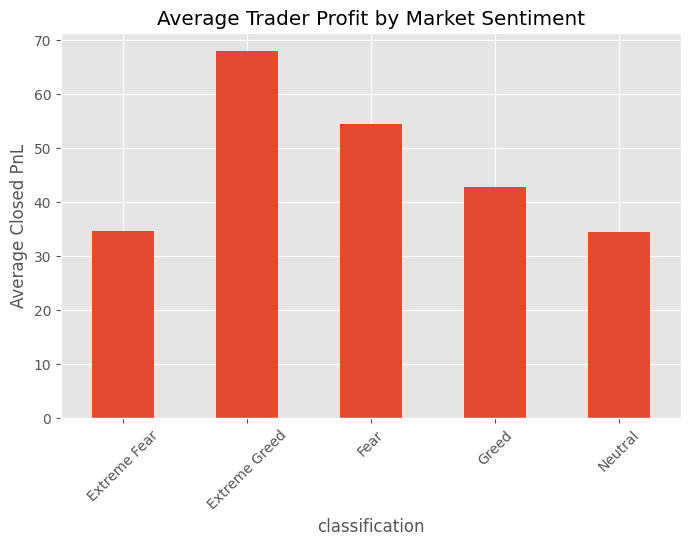

In [23]:
plt.figure(figsize=(8,5))

profit_analysis.plot(kind='bar')

plt.title('Average Trader Profit by Market Sentiment')

plt.ylabel('Average Closed PnL')

plt.xticks(rotation=45)

plt.savefig('Avg Trader Profit by Market Sentiment.png', bbox_inches='tight')

plt.show()

### Observation 

->Trader profitability varies noticeably across different market sentiment conditions.

->The highest average profitability occurs during Extreme Greed, potentially due to strong & increased market participation.

->Fear periods also show relatively strong profitability

->Extreme Fear and Neutral conditions demonstrate comparatively lower average profits, suggesting reduced trading confidence and less favorable market conditions.

->this completes our first objective of exploring the relationship between trader performance and market 
sentiment


In [15]:
#Now to uncover some hidden patterns or relations, let's dive into buy vs Sell tendencies based on sentiments

buy_sell = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


## observation 
->Buying and selling trends remain quite balanced across all sentiments

In [16]:
trade_frequency = merged.groupby(
    'classification'
).size()

print(trade_frequency)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


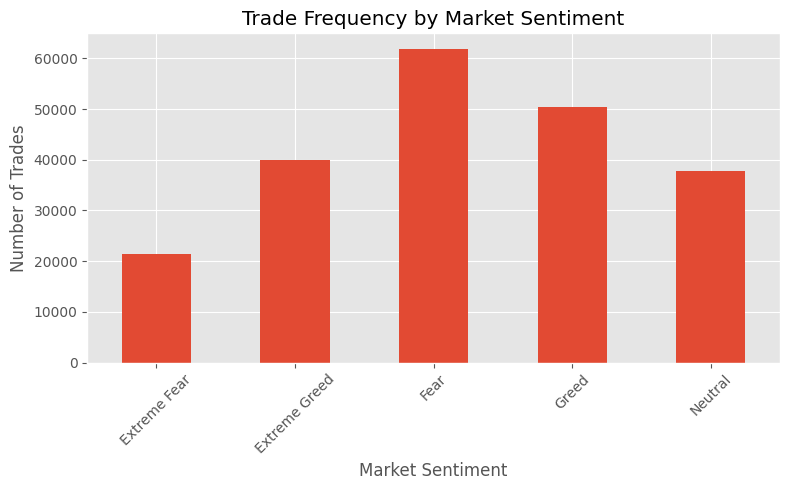

In [22]:
trade_frequency.plot(
    kind='bar',
    figsize=(8,5),
    title='Trade Frequency by Market Sentiment'
)

plt.ylabel('Number of Trades')
plt.xlabel('Market Sentiment')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('Trade Frequency vs Marker Sentiment.png', bbox_inches='tight')
plt.show()

### Observation 

Trade frequency varies significantly across different market sentiment conditions.

The highest trading activity occurs during moderate Fear and Greed phases, while Extreme Fear shows the lowest participation levels. Interestingly, trade frequency during Extreme Greed is also lower than during standard Greed conditions.

These findings suggest that traders may prefer participating during more stable directional markets while becoming relatively cautious during highly emotional or volatile market environments.

## Part-B Segmentation

In [24]:
#segment -1 Frequent vs Infrequent traders

#create trade counts
trade_counts = merged.groupby(
    'Account'
).size()

#define frequent traders
median_trades = trade_counts.median()

frequent_traders = trade_counts[
    trade_counts > median_trades
].index 

#label then
merged['Trader Segment'] = merged['Account'].apply(
    lambda x: 'Frequent'
    if x in frequent_traders
    else 'Infrequent'
)



In [25]:
#analysing the Label with PnL

segment_pnl = merged.groupby(
    'Trader Segment'
)['Closed PnL'].mean()

print(segment_pnl)

Trader Segment
Frequent      42.493421
Infrequent    95.216371
Name: Closed PnL, dtype: float64


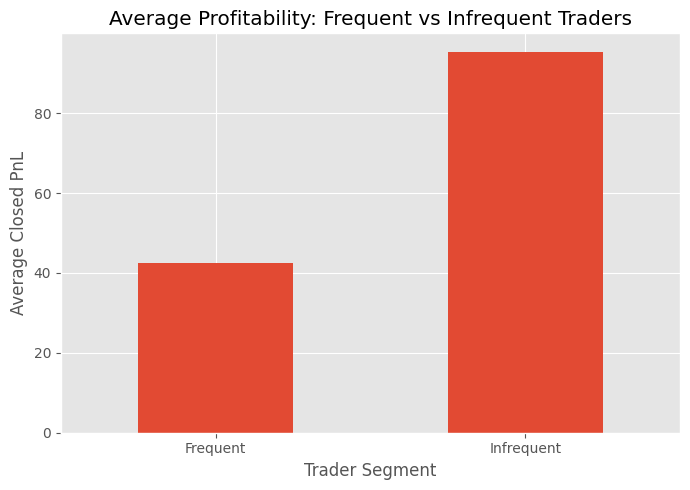

In [26]:
segment_pnl.plot(
    kind='bar',
    figsize=(7,5),
    title='Average Profitability: Frequent vs Infrequent Traders'
)

plt.ylabel('Average Closed PnL')
plt.xticks(rotation=0)
plt.savefig('Profitablility_Freq_vs_Infreq_Traders.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

### Observation 

Trader segmentation based on trading frequency reveals that infrequent traders achieve significantly higher average profitability compared to frequent traders.

This suggests that excessive trading activity may reduce trade quality and overall performance, potentially due to overtrading and increased exposure to market noise.

The findings indicate that selective participation and disciplined trade execution may be more effective than high-frequency trading behavior for many market participants.

In [27]:
#Segment 2- Consistent Winner

#defining winrate
trader_winrate = merged.groupby(
    'Account'
)['win'].mean()

#define consistent winner
consistent = trader_winrate[
    trader_winrate > 0.6
].index

In [28]:

#Label
merged['Consistency'] = merged['Account'].apply(
    lambda x: 'Consistent Winner'
    if x in consistent
    else 'Others'
)

#analyse
consistency_analysis = merged.groupby(
    'Consistency'
)['Closed PnL'].mean()

print(consistency_analysis)

Consistency
Consistent Winner    38.319560
Others               49.051988
Name: Closed PnL, dtype: float64


### Observation

Traders classified as “Consistent Winners” based on win rate do not necessarily achieve the highest average profitability.

While these traders win more frequently, their average profits remain lower than the broader trader population, suggesting that consistent trading strategies may prioritize stability and smaller gains over high-risk, high-reward opportunities.

This highlights the importance of balancing win rate with overall risk-reward efficiency when evaluating trading performance.

### let's find top 10 traders and analyse their trading patterns to gain smarter trading strategies

In [31]:


top_accounts = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending = False).head(10).index


In [33]:
top_traders = merged[merged['Account'].isin(top_accounts)]
top_sentiment_profit = top_traders.groupby(
    'classification'
)['Closed PnL'].mean()

print(top_sentiment_profit)

classification
Extreme Fear      60.765008
Extreme Greed    136.960455
Fear              66.979192
Greed             93.526109
Neutral           53.831636
Name: Closed PnL, dtype: float64


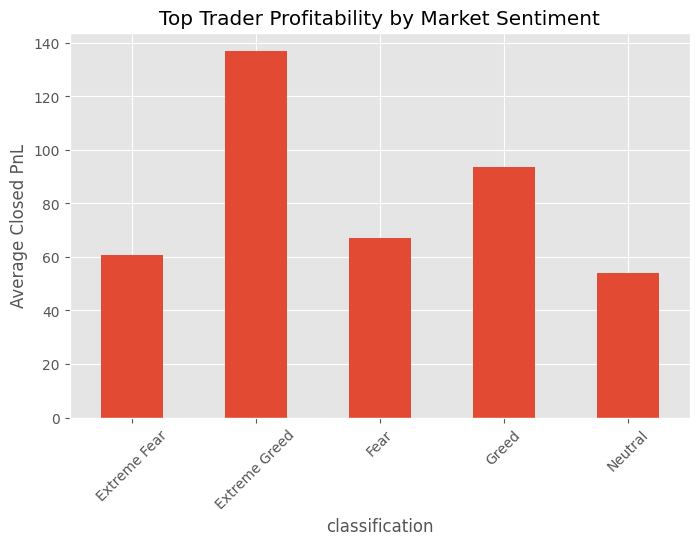

In [34]:
plt.figure(figsize=(8,5))

top_sentiment_profit.plot(kind='bar')

plt.title('Top Trader Profitability by Market Sentiment')

plt.ylabel('Average Closed PnL')

plt.xticks(rotation=45)
plt.show()

### Observation

->Top-performing traders remain profitable across all market sentiment conditions, demonstrating strong adaptability to changing market environments.

->Their profitability is highest during Extreme Greed periods, where average profits rise significantly compared to other sentiment phases. This suggests that experienced traders are particularly effective at capitalizing on high market participation.

-> One could focus on using this sentiment time for maximum gains.

In [35]:
#what do we gain from it, let's try 'Size USD'(position Size) Vs Market sentiment to see
#what Position sizes to choose in various market conditions

top_size_analysis = top_traders.groupby(
    'classification'
)['Size USD'].mean()

print(top_size_analysis)

classification
Extreme Fear     3817.090117
Extreme Greed    3561.086032
Fear             8579.253851
Greed            9065.242061
Neutral          5487.740626
Name: Size USD, dtype: float64


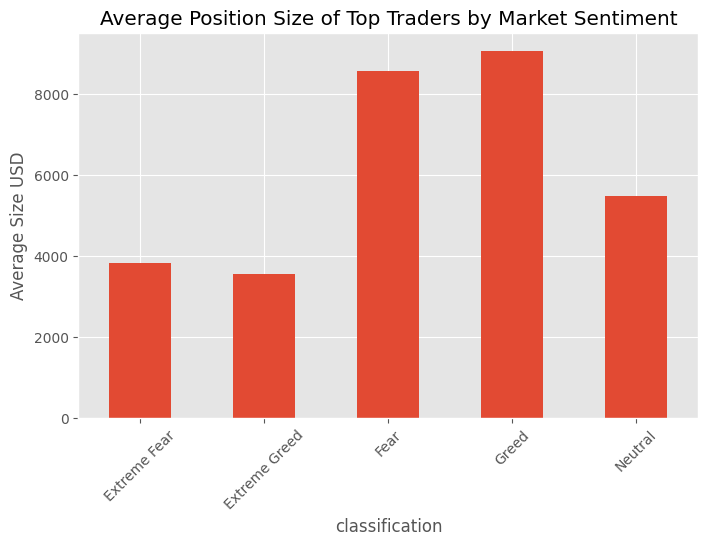

In [36]:
top_size_analysis.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Position Size of Top Traders by Market Sentiment'
)

plt.ylabel('Average Size USD')
plt.xticks(rotation=45)
plt.savefig('TopTraders Position size vs Market Sentiment.png', bbox_inches='tight')

plt.show()

### Observation

->Top-performing traders demonstrate noticeable changes in position sizing across different market sentiment conditions.

->Interestingly, the largest average position sizes occur during moderate Fear and Greed phases, while both Extreme Fear and Extreme Greed periods show substantially smaller trade sizes.

->This suggests that elite traders may avoid excessive exposure during highly emotional or volatile market conditions. Instead of aggressively increasing risk during euphoric or panic-driven markets, top traders appear to prioritize disciplined position sizing and controlled risk management.

->These findings indicate that reducing exposure during extreme sentiment conditions may contribute to more stable long-term trading performance.

## Part-C : Actionable Output


## 1. Follow Risk Management Patterns Used by Top Traders

Top-performing traders showed significantly smaller average position sizes during Extreme Fear and Extreme Greed conditions, while allocating larger positions during moderate Fear and Greed phases.

This suggests that experienced traders avoid aggressive exposure during highly emotional market environments and instead increase participation during relatively stable trend conditions.

A practical strategy implication is to reduce position sizes during euphoric or panic-driven markets and prioritize controlled exposure during more balanced market phases.


## 2. Avoid Excessive Trading Activity

The analysis shows that infrequent traders achieved significantly higher average profitability compared to frequent traders.

This suggests that overtrading may reduce trade quality and increase exposure to market noise. Traders may benefit from focusing on higher-conviction setups rather than maintaining constant market participation.

---


## 3. Reduce Exposure During Extreme Sentiment Conditions

Top-performing traders used noticeably smaller average position sizes during both Extreme Fear and Extreme Greed conditions.

This indicates that disciplined traders may intentionally reduce exposure during highly emotional or volatile market phases to manage downside risk more effectively.

---

## 4. Favor Moderate Market Conditions Over Emotional Extremes

Trading activity and profitability were strongest during moderate Fear and Greed conditions, while Extreme Fear showed lower participation and smaller position sizes.

This suggests that more stable directional market environments may provide better trading opportunities than emotionally overheated or panic-driven conditions.

---